In [9]:
import pandas as pd

# File pathway
RAW_PATH = '/home/rt334/Downloads/MEDUSA_Master_Dataset_UPDATED.csv'

# ---------------------------------------------------------------------------
# Self-contained cleaning step. The previous version of this script assumed
# an already-cleaned file existed as input, which caused a KeyError when run
# directly on the raw download (raw file still has anonymised column names
# and two trailing MEDDESCRIPTION/MEDFEATURE label rows). This mirrors the
# same cleaning logic used in the PCA script so this script works standalone.
# ---------------------------------------------------------------------------
df = pd.read_csv(RAW_PATH, low_memory=False)
id_col = 'MEDUSA_Subject_ID' if 'MEDUSA_Subject_ID' in df.columns else df.columns[0]

desc_mask = df[id_col].astype(str) == 'MEDDESCRIPTION'
if desc_mask.any():
    desc_row = df[desc_mask].iloc[0]
    rename_map = {c: desc_row[c] for c in df.columns
                  if c != id_col and pd.notna(desc_row[c]) and desc_row[c] != c}
    df = df.rename(columns=rename_map)
    print(f"Renamed {len(rename_map)} columns to their real feature names.")
else:
    print("No MEDDESCRIPTION row found — assuming file is already cleaned/renamed.")

label_rows = df[id_col].astype(str).str.contains('MEDDESCRIPTION|MEDFEATURE', na=False)
if label_rows.any():
    print(f"Removing {label_rows.sum()} trailing label rows.")
    df = df[~label_rows].copy()

# Mutation/loss/gain columns get read as TEXT because of the label rows above
# — convert to numeric, or they'll be silently skipped by anything numeric.
mutation_like = [c for c in df.columns if str(c).startswith(
    ('Mutation ', 'Loss ', 'Gain ', 'DriverLoss', 'DriverGain'))]
for c in mutation_like:
    df[c] = pd.to_numeric(df[c], errors='coerce')

for numeric_col in ['Age', 'ageAcc.Horvath', 'ScarHRD sum score',
                     'Overall BAP1 IHC (1=positive/retained, 0=negative/loss)',
                     'Overall survival (Surgery-to-Death) in days']:
    if numeric_col in df.columns:
        df[numeric_col] = pd.to_numeric(df[numeric_col], errors='coerce')

print(f"Loaded and cleaned: {df.shape[0]} patients, {df.shape[1]} columns.\n")

clin = df[df['Age'].notna()]

# Table A: Patient characteristics
hist_map = {1.0: 'Group 1 (n=88, likely Epithelioid)',
            2.0: 'Group 2 (n=1, likely Sarcomatoid)',
            3.0: 'Group 3 (n=8, likely Biphasic)'}
table_a_rows = []
table_a_rows.append({'Variable': 'Age (years)', 'Summary': f"Mean {clin['Age'].mean():.1f} (SD {clin['Age'].std():.1f}), range {clin['Age'].min():.0f}-{clin['Age'].max():.0f}", 'n': len(clin)})
for label, count in clin['Histology'].map(hist_map).value_counts().items():
    table_a_rows.append({'Variable': f'Histology: {label}', 'Summary': f'n={count}', 'n': count})
for label, count in clin['Gender '].map({1.0: 'Male', 2.0: 'Female'}).value_counts().items():
    table_a_rows.append({'Variable': f'Gender: {label}', 'Summary': f'n={count}', 'n': count})
for label, count in clin['IMIG Stage'].value_counts().items():
    table_a_rows.append({'Variable': f'IMIG Stage: {label}', 'Summary': f'n={count}', 'n': count})
for label, count in clin['Asbestos exposure'].value_counts(dropna=False).items():
    table_a_rows.append({'Variable': f'Asbestos exposure: {label}', 'Summary': f'n={count}', 'n': count})
for label, count in clin['Smoking status'].value_counts(dropna=False).items():
    table_a_rows.append({'Variable': f'Smoking status: {label}', 'Summary': f'n={count}', 'n': count})

pd.DataFrame(table_a_rows).to_csv('table_patient_characteristics.csv', index=False) 

# Table B: data availability by modality
modalities = {
    'Clinical/pathological (Age, Histology, Stage)': df['Age'].notna().sum(),
    'Methylation (9 epigenetic clocks)': df['ageAcc.Horvath'].notna().sum(),
    'RNA-seq (ssGSEA hallmark pathways)': df['ssGSEA:HALLMARK_ADIPOGENESIS'].notna().sum(),
    'WES/genomic (mutation & SCNA calls)': df['Mutation BAP1'].notna().sum(),
    'HRD scores': df['ScarHRD sum score'].notna().sum(),
    'BAP1 IHC': df['Overall BAP1 IHC (1=positive/retained, 0=negative/loss)'].notna().sum(),
    'Overall survival data': df['Overall survival (Surgery-to-Death) in days'].notna().sum(),
}
pd.DataFrame([{'Data modality': k, 'n patients': v, '% of cohort (n=237)': round(v/237*100, 1)}
              for k, v in modalities.items()]).to_csv('table_data_availability.csv', index=False)

# Table C: feature counts by category
categories = {
    'Methylation clocks (ageAcc)': [c for c in df.columns if c.startswith('ageAcc')],
    'RNA-seq hallmark pathways (ssGSEA)': [c for c in df.columns if c.startswith('ssGSEA:')],
    'Immune cell deconvolution': [c for c in df.columns if any(c.startswith(p) for p in ['ConsensusTME','Cibersort','xCell'])],
    'Driver mutations': [c for c in df.columns if c.startswith('Mutation ')],
    'Chromosome arm SCNA (Loss/Gain)': [c for c in df.columns if c.startswith(('Loss ','Gain '))],
    'Driver SCNA / HRD / TMB': [c for c in df.columns if c.startswith(('DriverLoss','DriverGain','ScarHRD')) or 'TMB' in c],
    'Clinical/pathological': ['Age','Gender ','Histology','pT stage','p N stage','IMIG Stage'],
    'Survival/outcome': [c for c in df.columns if 'survival' in c.lower() or 'Status' in c],
}
pd.DataFrame([{'Data category': k, 'n features': len(v)} for k, v in categories.items()]
             ).to_csv('table_feature_categories.csv', index=False)

print("Saved 3 tables: table_patient_characteristics.csv, table_data_availability.csv, table_feature_categories.csv")

Renamed 982 columns to their real feature names.
Removing 2 trailing label rows.
Loaded and cleaned: 235 patients, 1277 columns.

Saved 3 tables: table_patient_characteristics.csv, table_data_availability.csv, table_feature_categories.csv


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# just trying to make the csv tables look decent as images so i can drop them
# into the dissertation without manually retyping everything in word

header_col = "steelblue"
alt_row = "whitesmoke"
border_col = "lightgrey"


def make_table_png(csv, out, title=None, widths=None, nrows=None):
    # read the csv file
    df = pd.read_csv(csv)

    # only keep the requested number of rows if needed
    if nrows is not None:
        df = df.head(nrows)

    rows, cols = df.shape

    # automatically make the figure large enough for the table
    figure_height = max(6, 0.55 * (rows + 2))
    figure_width = max(14, 3.2 * cols)

    fig, ax = plt.subplots(
        figsize=(figure_width, figure_height)
    )

    ax.axis("off")

    # add the table title
    if title:
        ax.set_title(
            title,
            fontsize=16,
            fontweight="bold",
            loc="left",
            pad=20
        )

    # create the table
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="left",
        colLoc="center",
        loc="center",
        colWidths=widths
    )

    # stop matplotlib from automatically shrinking the font
    table.auto_set_font_size(False)
    table.set_fontsize(11)

    # make the cells wider and taller
    table.scale(1.15, 1.9)

    # format the header and alternating rows
    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor(border_col)
        cell.set_linewidth(0.8)

        if row == 0:
            cell.set_facecolor(header_col)
            cell.set_text_props(
                color="white",
                fontweight="bold",
                ha="center"
            )

        elif row % 2 == 0:
            cell.set_facecolor(alt_row)

        else:
            cell.set_facecolor("white")

        # add a little internal spacing around the text
        cell.PAD = 0.10

    plt.tight_layout()

    # save a high-resolution image suitable for the dissertation
    plt.savefig(
        out,
        dpi=600,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close()

    print("saved", out)


# table 1 - patient characteristics
make_table_png(
    "table_patient_characteristics.csv",
    "table_patient_characteristics.png",
    title="Patient characteristics (n=97 with clinical/pathological data)",
    widths=[0.48, 0.40, 0.12]
)


# table 2 - data availability
make_table_png(
    "table_data_availability.csv",
    "table_data_availability.png",
    title="Data availability by modality (n=237 total MEDUSA patients)",
    widths=[0.58, 0.21, 0.21]
)


# table 3 - feature counts
make_table_png(
    "table_feature_categories.csv",
    "table_feature_categories.png",
    title="Feature counts by data category",
    widths=[0.78, 0.22]
)

saved table_patient_characteristics.png
saved table_data_availability.png
saved table_feature_categories.png


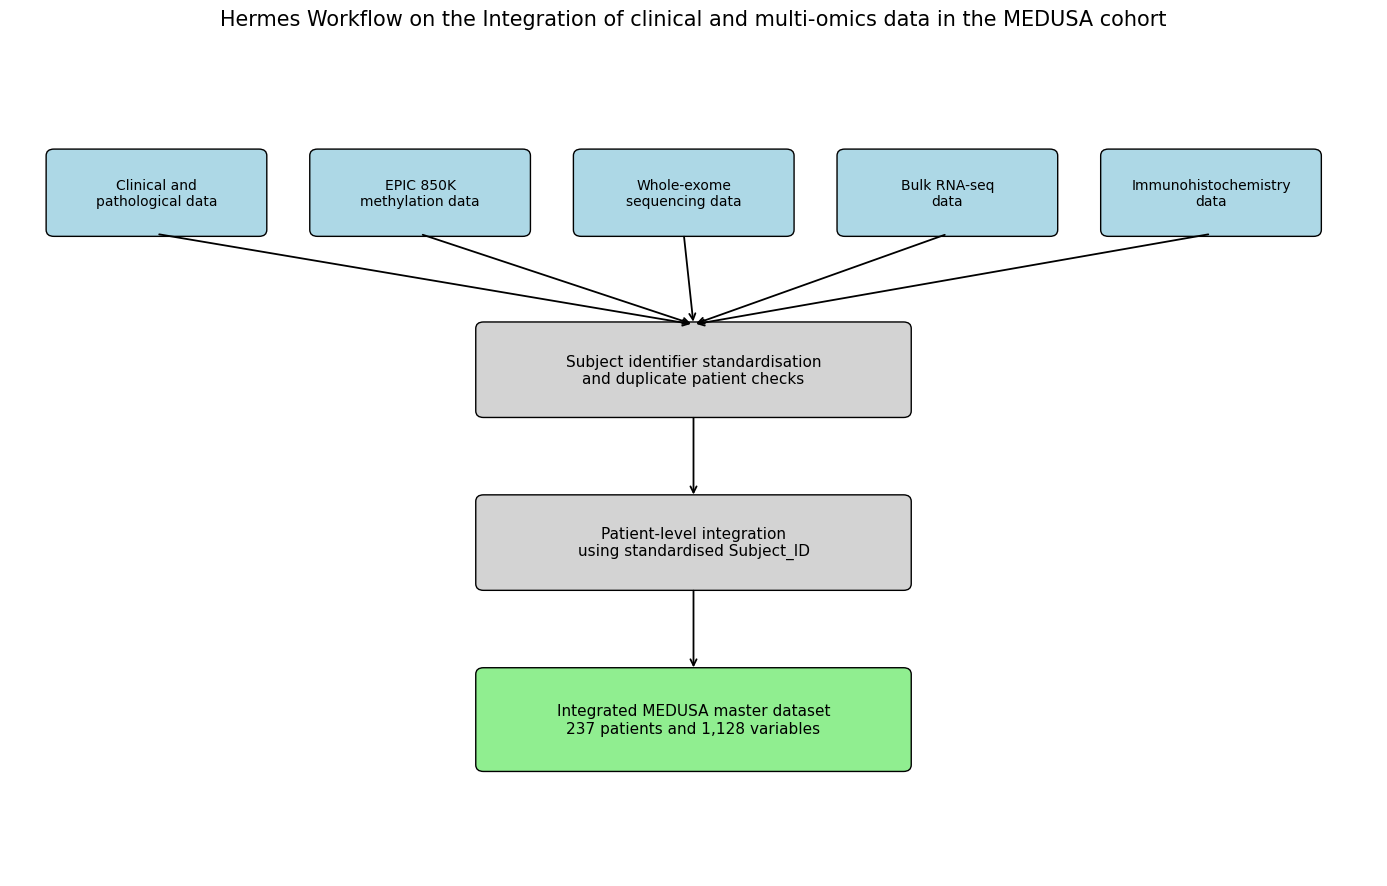

In [14]:
# Figure 3 – MEDUSA data integration workflow

fig, ax = plt.subplots(figsize=(14, 9))

ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis("off")


def add_box(
    ax,
    x,
    y,
    width,
    height,
    text,
    facecolour="whitesmoke",
    fontsize=10
):
    """
    Add a rounded rectangular box to the workflow.
    """

    box = patches.FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        facecolor=facecolour,
        edgecolor="black",
        linewidth=1.0
    )

    ax.add_patch(box)

    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize
    )

    return box


def add_arrow(
    ax,
    start_x,
    start_y,
    end_x,
    end_y
):
    """
    Add an arrow between workflow stages.
    """

    ax.annotate(
        "",
        xy=(end_x, end_y),
        xytext=(start_x, start_y),
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1.3,
            "color": "black"
        }
    )


# Source datasets
source_width = 2.2
source_height = 1.0
source_y = 7.8

source_boxes = [
    (0.4, "Clinical and\npathological data"),
    (3.1, "EPIC 850K\nmethylation data"),
    (5.8, "Whole-exome\nsequencing data"),
    (8.5, "Bulk RNA-seq\ndata"),
    (11.2, "Immunohistochemistry\ndata")
]

for x_position, label in source_boxes:
    add_box(
        ax,
        x=x_position,
        y=source_y,
        width=source_width,
        height=source_height,
        text=label,
        facecolour="lightblue"
    )


# Identifier standardisation
standardisation_x = 4.8
standardisation_y = 5.6
standardisation_width = 4.4
standardisation_height = 1.1

add_box(
    ax,
    x=standardisation_x,
    y=standardisation_y,
    width=standardisation_width,
    height=standardisation_height,
    text=(
        "Subject identifier standardisation\n"
        "and duplicate patient checks"
    ),
    facecolour="lightgrey",
    fontsize=11
)


# Arrows from source datasets
for x_position, _ in source_boxes:
    source_centre_x = x_position + source_width / 2

    add_arrow(
        ax,
        start_x=source_centre_x,
        start_y=source_y,
        end_x=7.0,
        end_y=standardisation_y + standardisation_height
    )


# Patient-level integration
integration_x = 4.8
integration_y = 3.5
integration_width = 4.4
integration_height = 1.1

add_box(
    ax,
    x=integration_x,
    y=integration_y,
    width=integration_width,
    height=integration_height,
    text=(
        "Patient-level integration\n"
        "using standardised Subject_ID"
    ),
    facecolour="lightgrey",
    fontsize=11
)

add_arrow(
    ax,
    start_x=7.0,
    start_y=standardisation_y,
    end_x=7.0,
    end_y=integration_y + integration_height
)


# Final master dataset
master_x = 4.8
master_y = 1.3
master_width = 4.4
master_height = 1.2

add_box(
    ax,
    x=master_x,
    y=master_y,
    width=master_width,
    height=master_height,
    text=(
        "Integrated MEDUSA master dataset\n"
        "237 patients and 1,128 variables"
    ),
    facecolour="lightgreen",
    fontsize=11
)

add_arrow(
    ax,
    start_x=7.0,
    start_y=integration_y,
    end_x=7.0,
    end_y=master_y + master_height
)


ax.set_title(
    "Hermes Workflow on the Integration of clinical and multi-omics data in the MEDUSA cohort",
    fontsize=15,
    pad=20
)

plt.tight_layout()

plt.savefig(
    output_dir / "Figure_3_MEDUSA_integration_workflow.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()